## Predictive Machine Learning & Deep Learning Model To Solve Classification Problem

### Datasets
The data is related with direct marketing campaigns of a Portuguese banking institution. The marketing campaigns were based on phone calls. Often, more than one contact to the same client was required, in order to access if the product (bank term deposit) would be ('yes') or not ('no') subscribed.
1) bank-additional-full.csv with all examples (41188) and 20 inputs, ordered by date (from May 2008 to November 2010), very close to the data analyzed in [Moro et al., 2014]

### Identify features that is most important in regards of (Customer Subscribed) to be presented to board, reccomend right promotional products to improve the total result of (Customer Subscribed) on the future marketing campaign.


In [54]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from xgboost import XGBClassifier
from xgboost import plot_importance
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
# For metrics and helpful functions
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.tree import plot_tree

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

In [9]:
path = r"C:\Users\Lim Otto\Downloads\bank-full.csv"
path2 = r"C:\Users\Lim Otto\Downloads\bank.csv"

In [12]:
df = pd.read_csv(path, sep=";")

In [19]:
df.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no


In [17]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [24]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [30]:
df.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [34]:
df.duplicated().sum()

0

In [36]:
df.shape

(45211, 17)

In [37]:
df['y'].value_counts()

no     39922
yes     5289
Name: y, dtype: int64

In [38]:
df['poutcome'].value_counts()

unknown    36959
failure     4901
other       1840
success     1511
Name: poutcome, dtype: int64

In [39]:
df_1 = df.copy()
df_1 = pd.get_dummies(df, drop_first=True)

In [41]:
df_1.head()

,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown,y_yes
0,58,2143,5,261,1,-1,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
1,44,29,5,151,1,-1,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
2,33,2,5,76,1,-1,0,0,1,0,...,0,0,1,0,0,0,0,0,1,0
3,47,1506,5,92,1,-1,0,1,0,0,...,0,0,1,0,0,0,0,0,1,0
4,33,1,5,198,1,-1,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0


In [58]:
corr = df_1.corr()['y_yes']
corr

age                    0.025155
balance                0.052838
day                   -0.028348
duration               0.394521
campaign              -0.073172
pdays                  0.103621
previous               0.093236
job_blue-collar       -0.072083
job_entrepreneur      -0.019662
job_housemaid         -0.015195
job_management         0.032919
job_retired            0.079245
job_self-employed      0.000855
job_services          -0.027864
job_student            0.076897
job_technician        -0.008970
job_unemployed         0.020390
job_unknown            0.000267
marital_married       -0.060260
marital_single         0.063526
education_secondary   -0.036388
education_tertiary     0.066448
education_unknown      0.012053
default_yes           -0.022419
housing_yes           -0.139173
loan_yes              -0.068185
contact_telephone      0.014042
contact_unknown       -0.150935
month_aug             -0.008536
month_dec              0.075164
month_feb              0.038417
month_ja

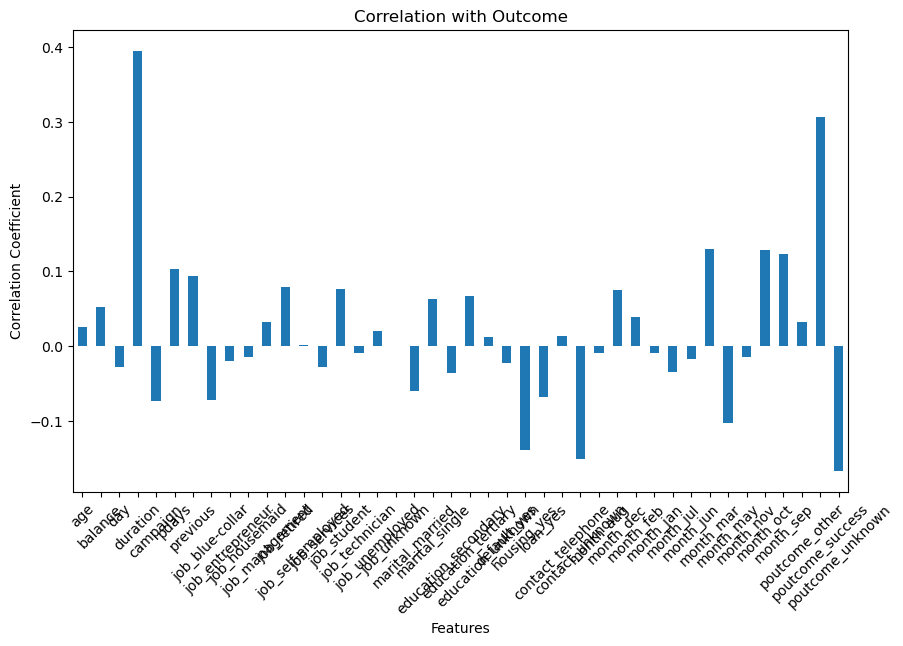

In [57]:
plt.figure(figsize=(10, 6))
corr.drop('y_yes').plot(kind='bar')
plt.title('Correlation with Outcome')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45)
plt.show()

In [43]:
df_1['y_yes'].value_counts(normalize=True)

0    0.883015
1    0.116985
Name: y_yes, dtype: float64

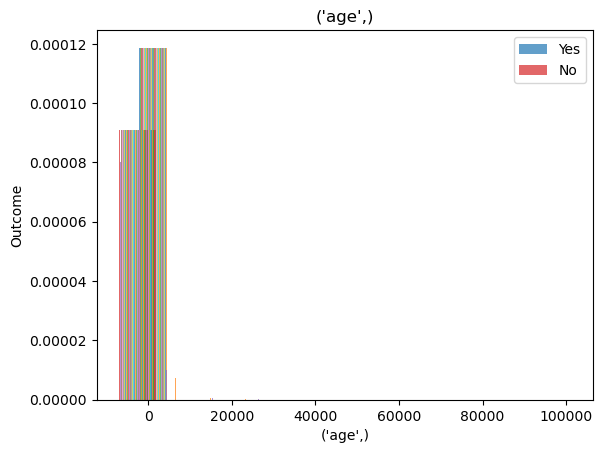

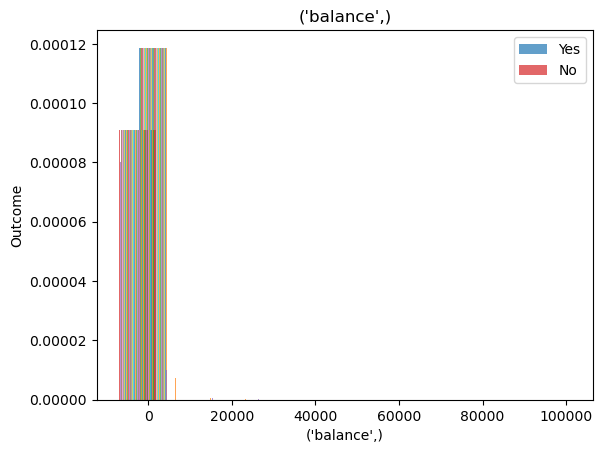

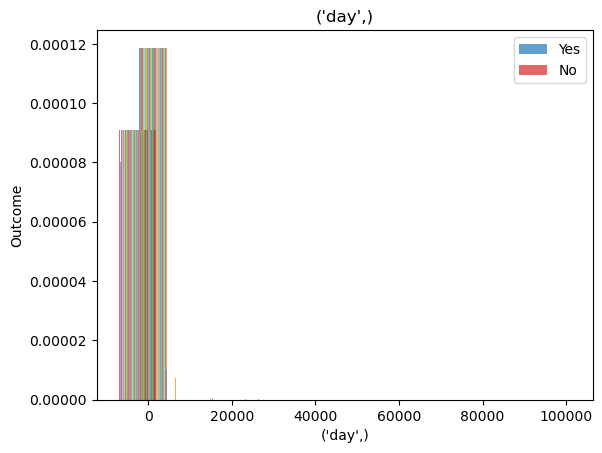

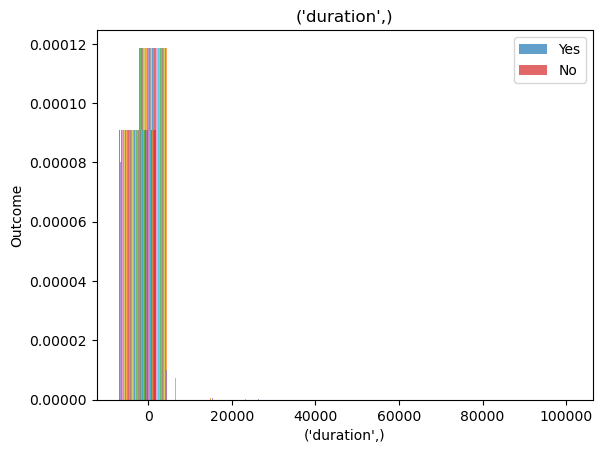

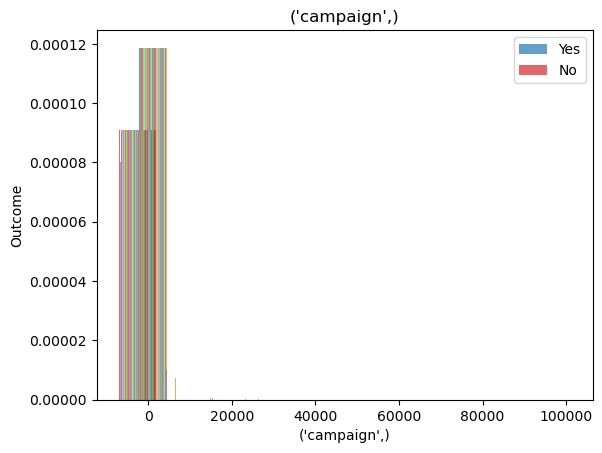

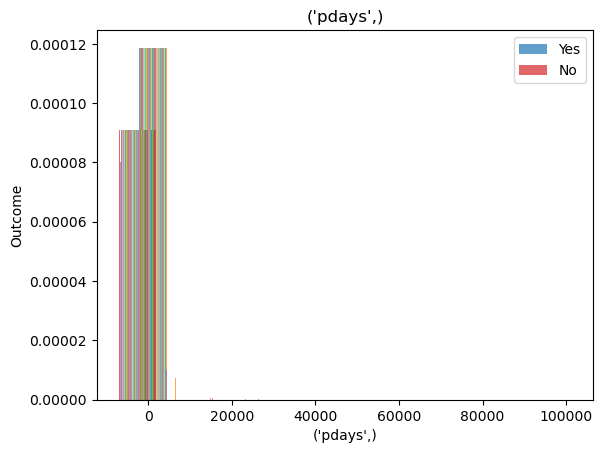

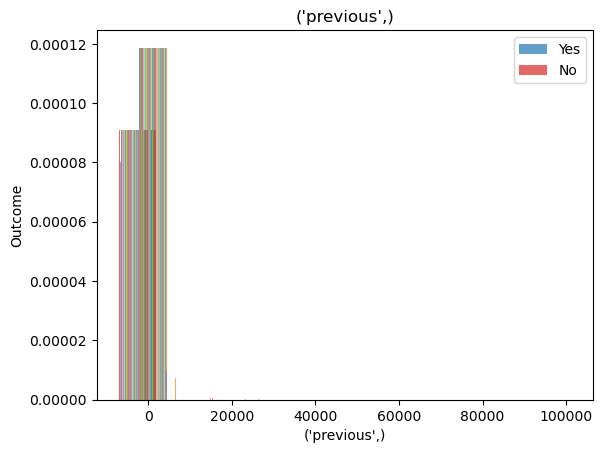

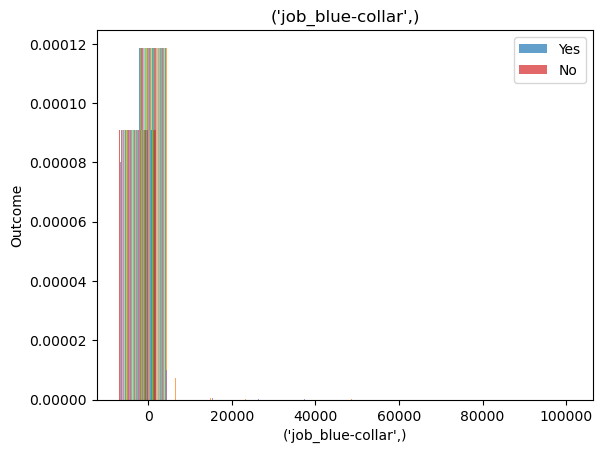

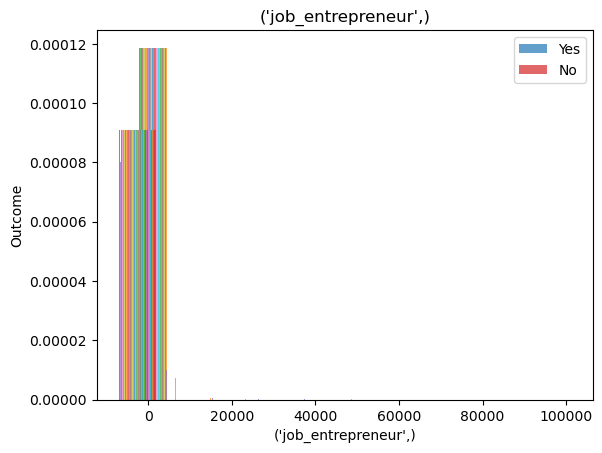

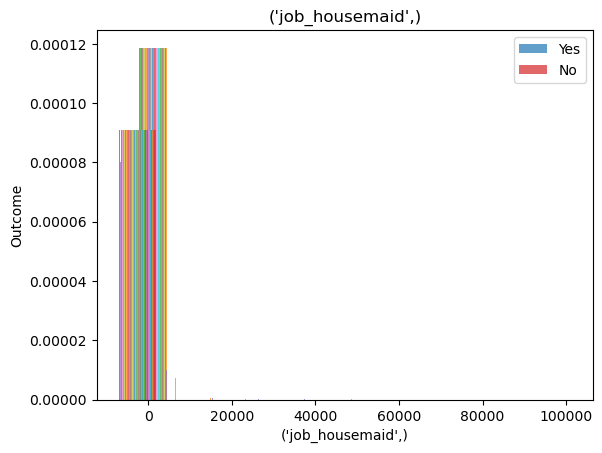

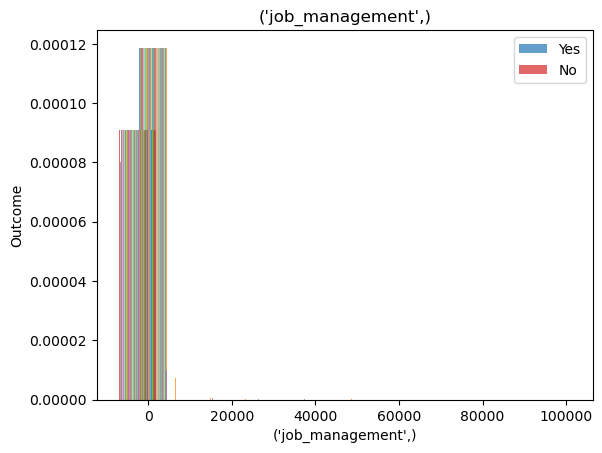

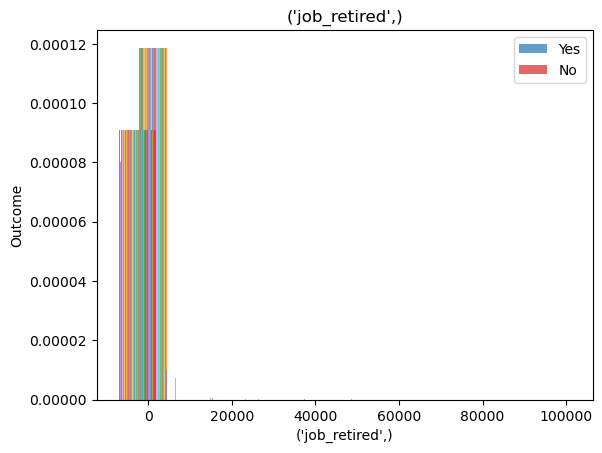

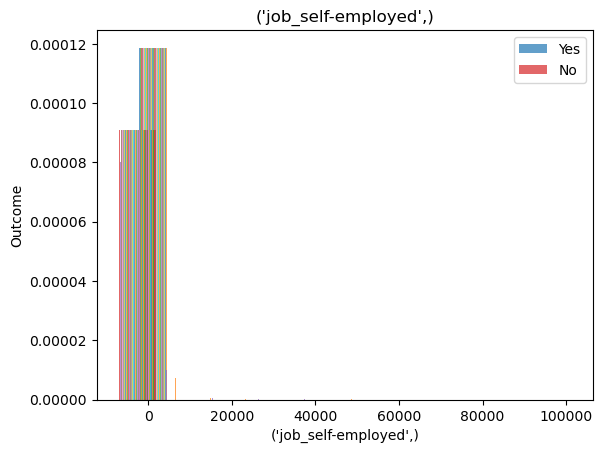

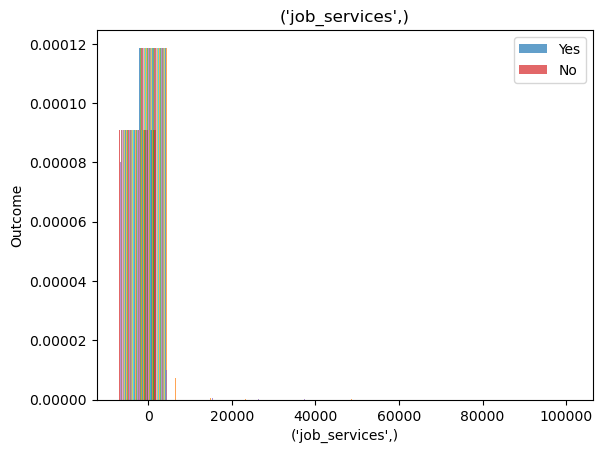

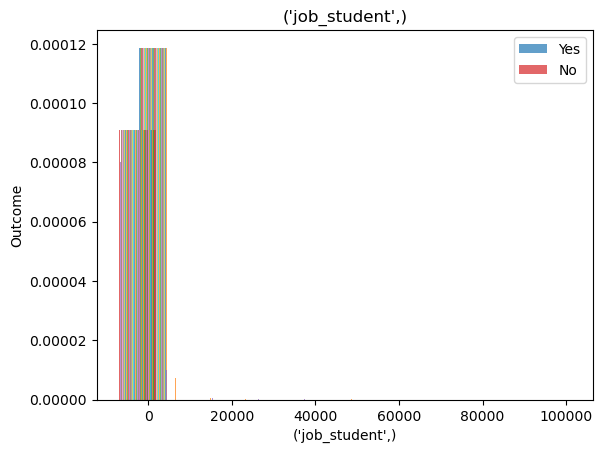

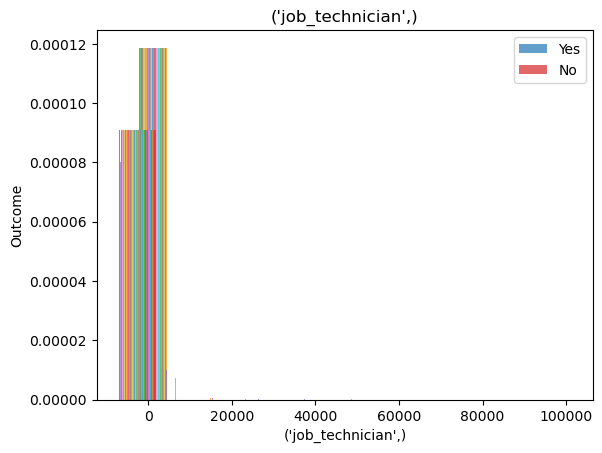

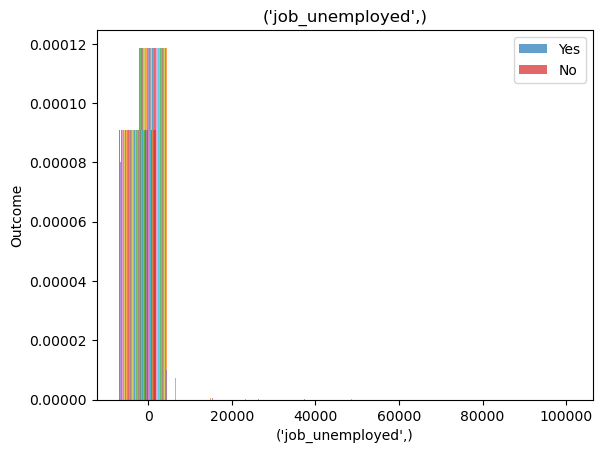

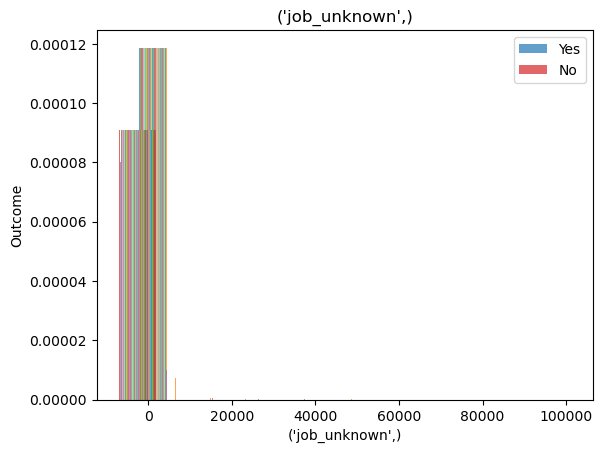

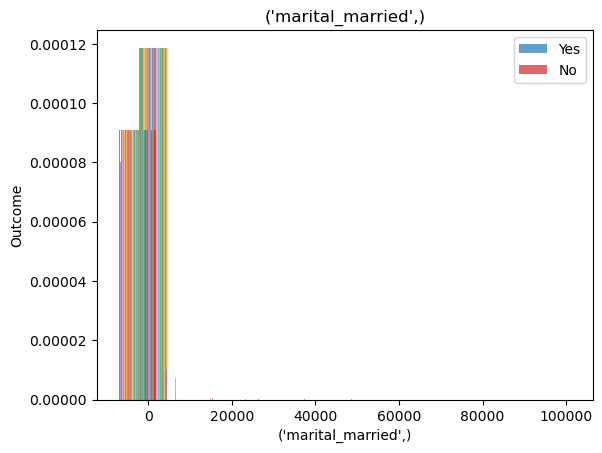

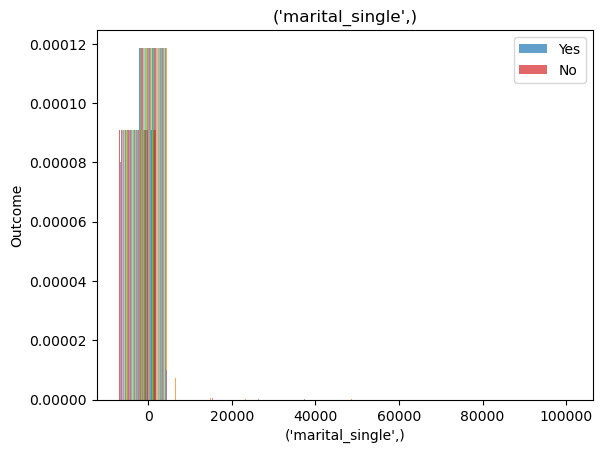

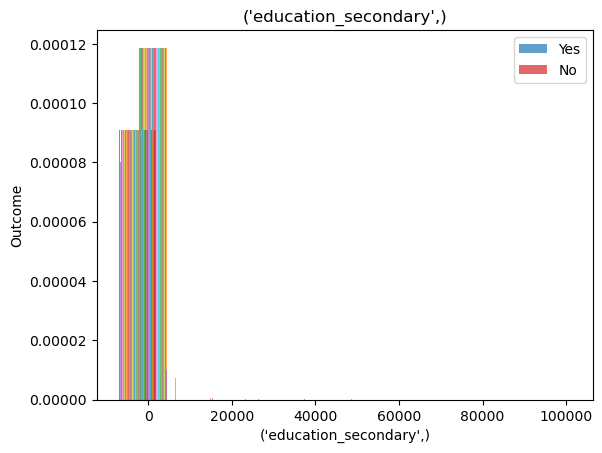

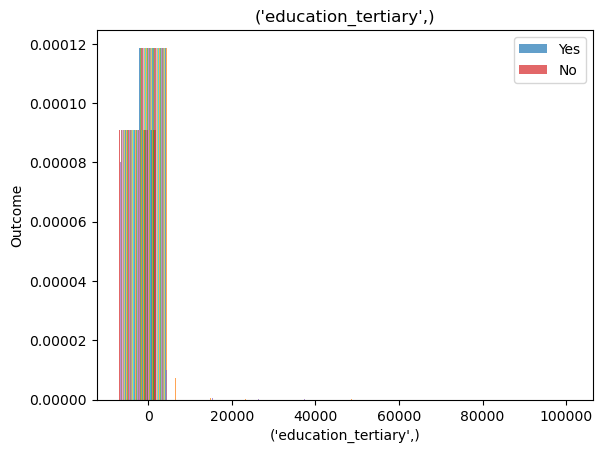

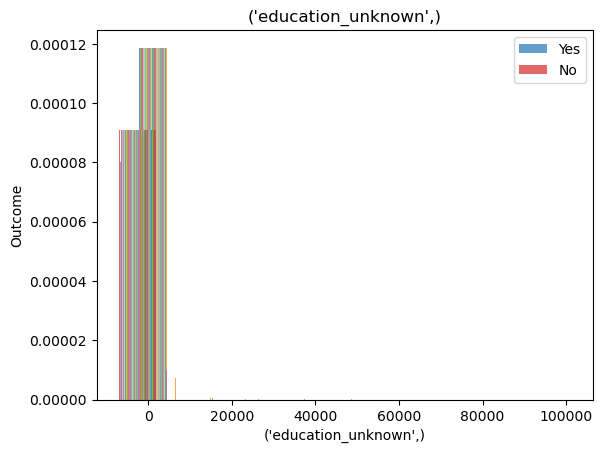

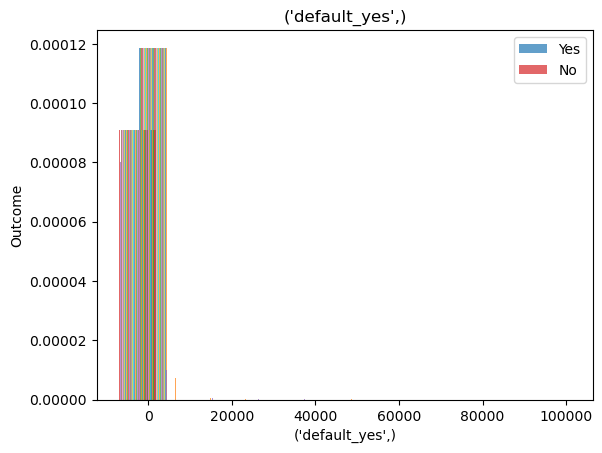

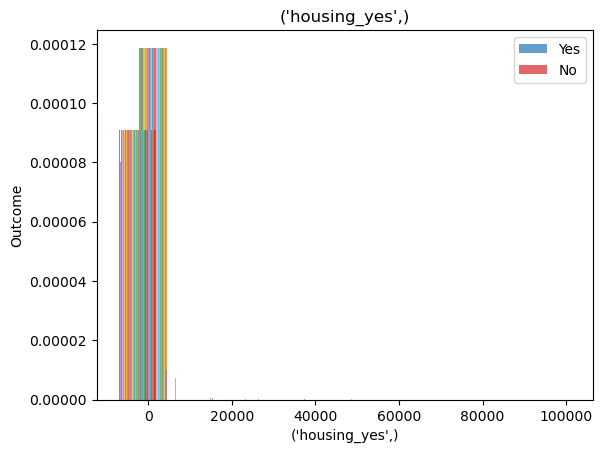

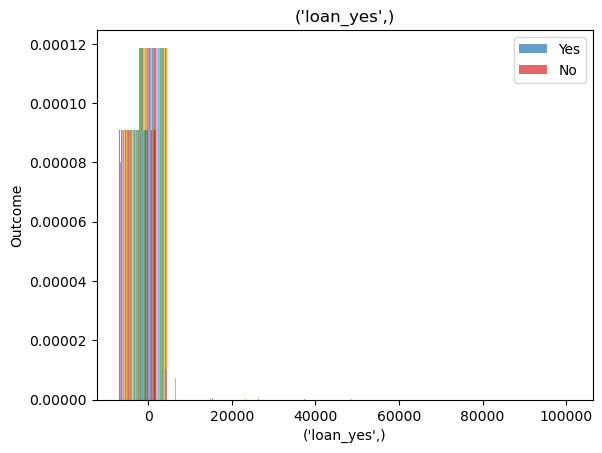

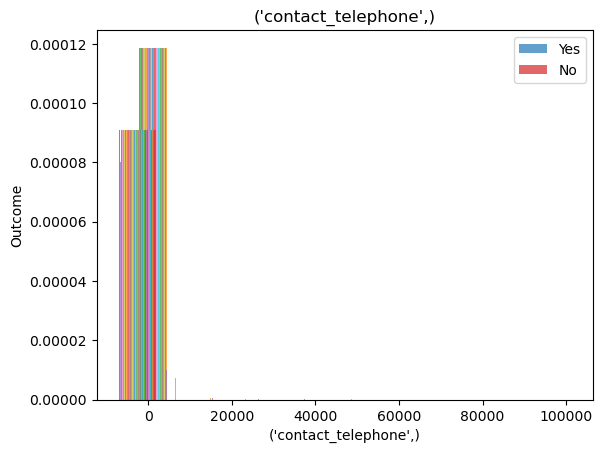

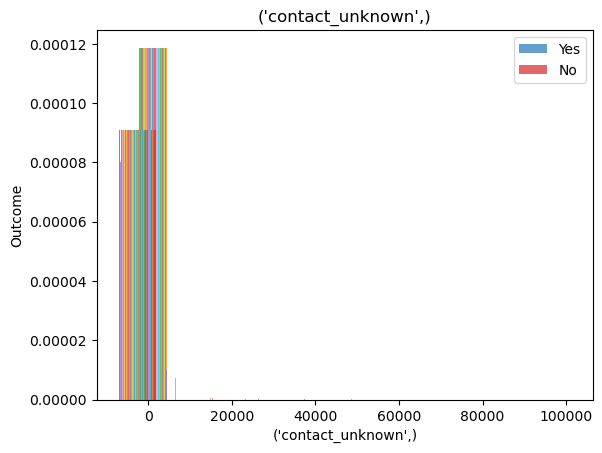

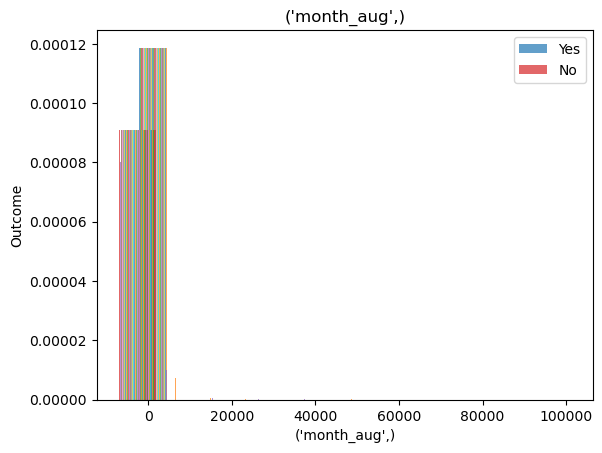

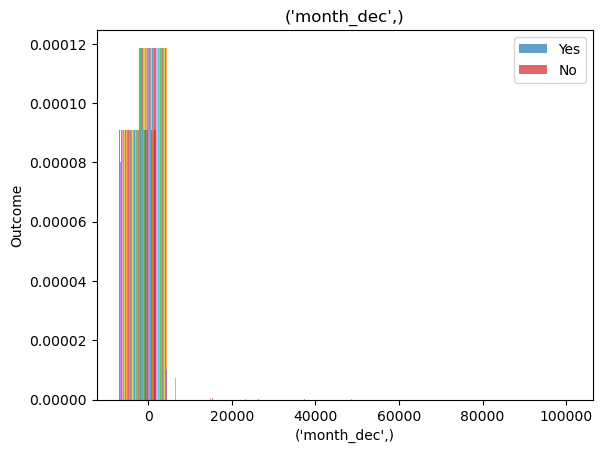

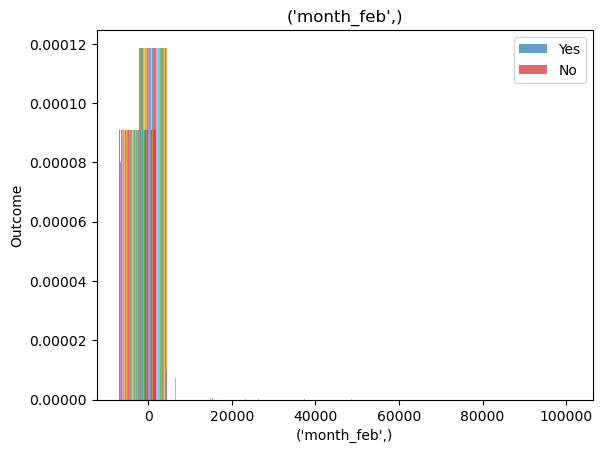

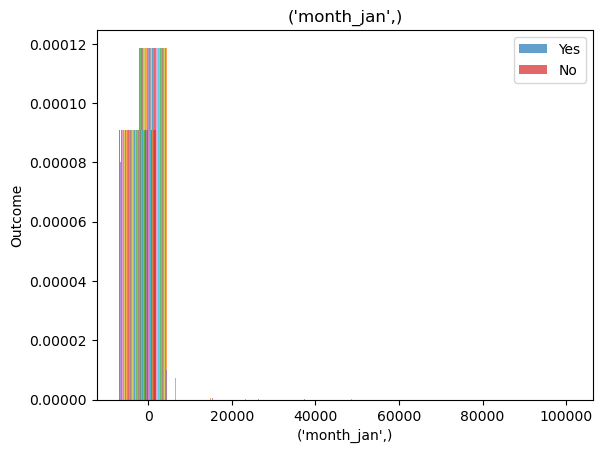

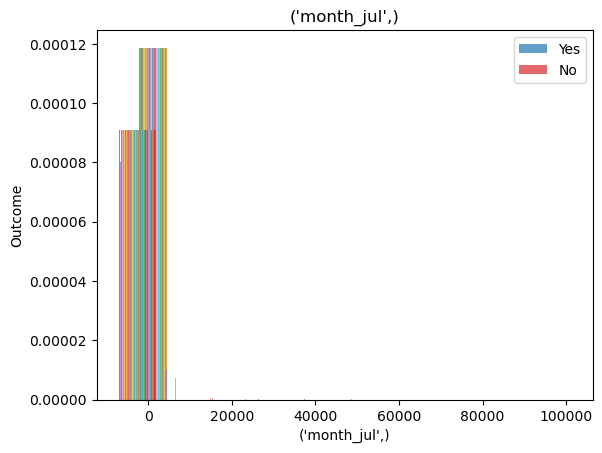

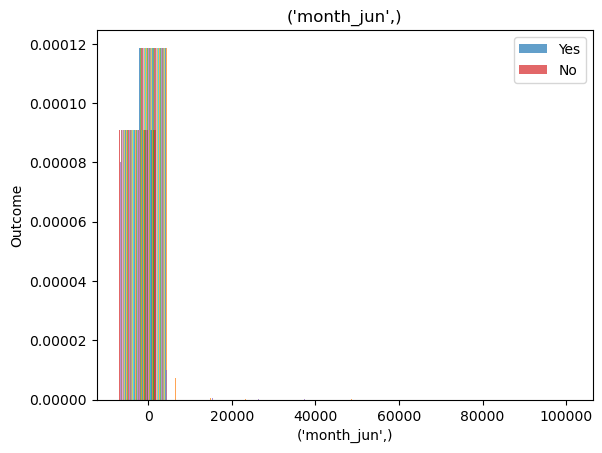

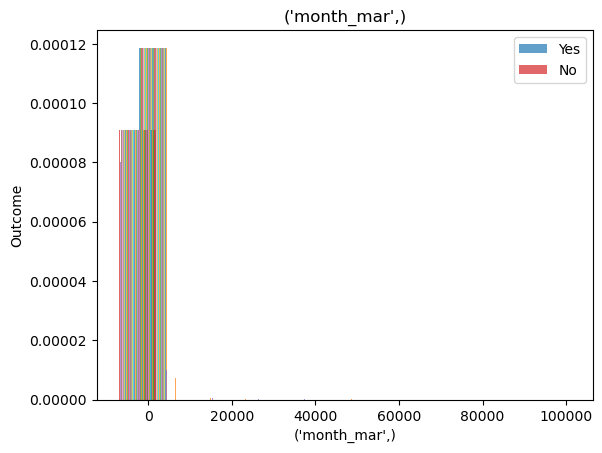

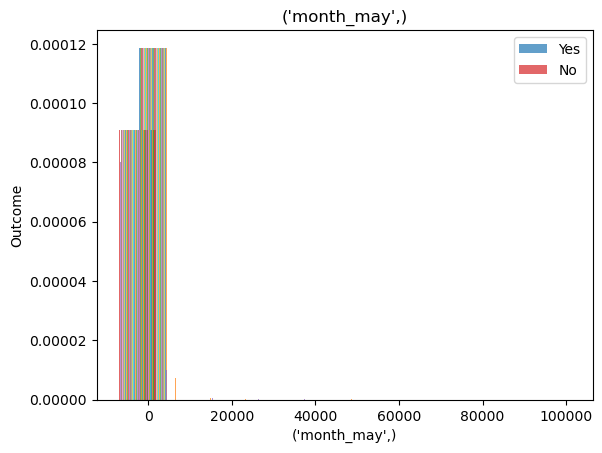

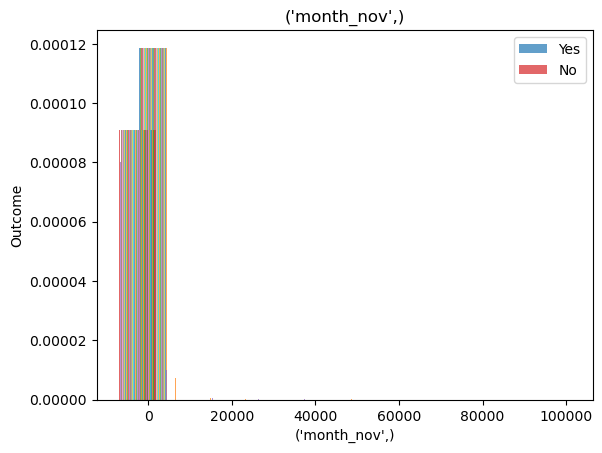

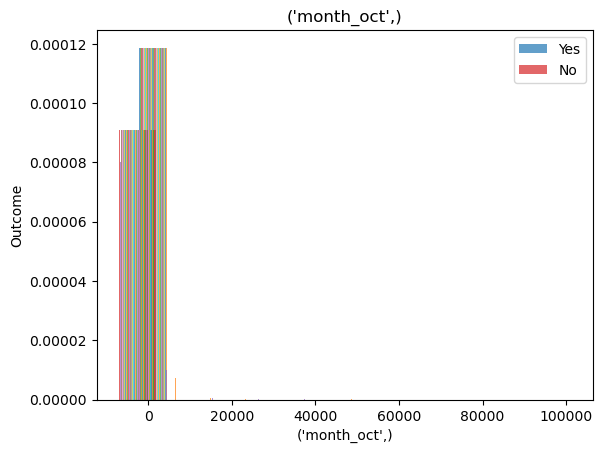

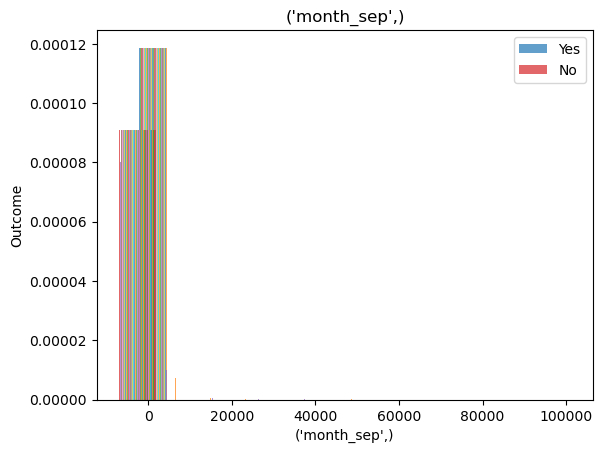

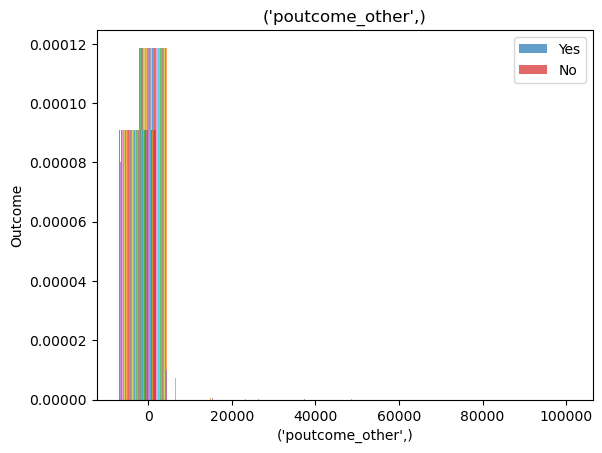

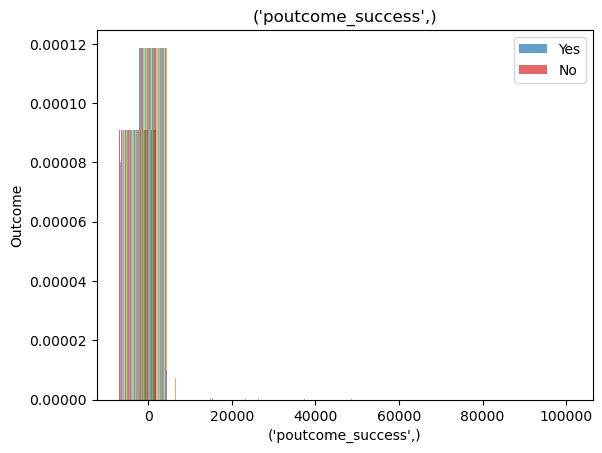

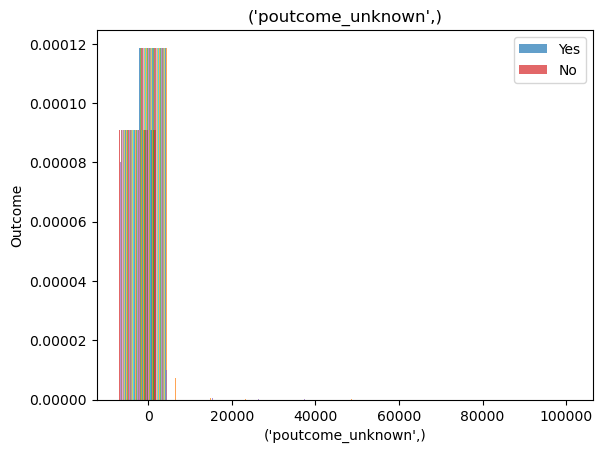

In [52]:
for i in range(len(df_1.columns[:-1])):
    label = df_1.columns[i],
    plt.hist(df_1[df_1['y_yes']==1], label='Yes', alpha=0.7, density=True)
    plt.hist(df_1[df_1['y_yes']==0], label='No', alpha=0.7, density=True)
    plt.title(label)
    plt.ylabel('Outcome')
    plt.xlabel(label)
    plt.legend()
    plt.show()

In [61]:
X = df_1.drop('y_yes', axis=1)
y = df_1['y_yes']

In [62]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

In [63]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

In [64]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [65]:
scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [66]:
#Modeling Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train_res, y_train_res)
y_gnb_val = gnb.predict(X_val)

In [68]:
y_gnb_train = gnb.predict(X_train_res)

In [70]:
#Evaluation metrics
y_gnb_train_acc = accuracy_score(y_train_res, y_gnb_train)
y_gnb_val_acc = accuracy_score(y_val, y_gnb_val)

print(y_gnb_train_acc)
print(y_gnb_val_acc)

0.8637654052970842
0.7994691831318195


In [122]:
variance_gnb = (y_gnb_train_acc-y_gnb_val_acc)
if variance_gnb > 0.075:
    print("gnb model is overfitted")
else:
    print("gnb model ready for prediction test")

gnb model ready for prediction test


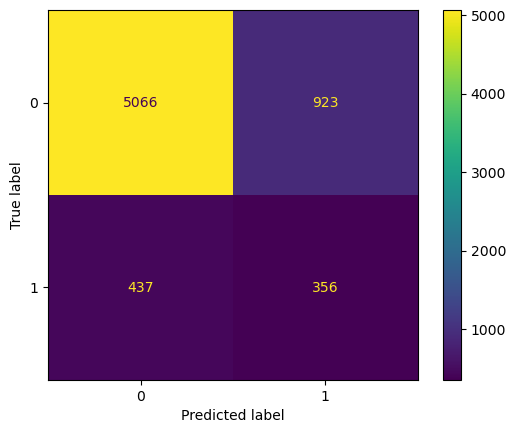

In [67]:
y_gnb_val_cm = confusion_matrix(y_val, y_gnb_val, labels=gnb.classes_)
# Create display of confusion matrix
gnb_disp = ConfusionMatrixDisplay(confusion_matrix=y_gnb_val_cm,
display_labels=gnb.classes_)
# Plot confusion matrix
gnb_disp.plot(values_format='')
# Display plot
plt.show()

In [123]:
y_gnb_pred = gnb.predict(X_test)

In [124]:
print('Accuracy score:', accuracy_score(y_test, y_gnb_pred))
print('Precision score:', precision_score(y_test, y_gnb_pred))
print('Recall score:', recall_score(y_test, y_gnb_pred))
print('F1 score:', f1_score(y_test, y_gnb_pred))

Accuracy score: 0.8013801645580819
Precision score: 0.27694538424359594
Recall score: 0.43343419062027233
F1 score: 0.33795340607490415


In [125]:
gnb_accuracy = accuracy_score(y_test, y_gnb_pred)
gnb_precision =  precision_score(y_test, y_gnb_pred)
gnb_recall = recall_score(y_test, y_gnb_pred)
gnb_f1 = f1_score(y_test, y_gnb_pred)
gnb_results = pd.DataFrame({'Model':[f"GNB"],
                          'F1': [gnb_f1],
                          'Recall': [gnb_recall],
                          'Precision': [gnb_precision],
                          'Accuracy': [gnb_accuracy]})
gnb_results

,Model,F1,Recall,Precision,Accuracy
0,GNB,0.337953,0.433434,0.276945,0.80138


In [72]:
%%time
model_rbf = SVC(kernel = 'rbf')
model_rbf.fit(X_train_res, y_train_res)
y_train_rbf = model_rbf.predict(X_train_res)
print('Accuracy of rbf model', accuracy_score(y_train_res, y_train_rbf))

Accuracy of rbf model 0.9486323102100799
CPU times: total: 2min 11s
Wall time: 5min 31s


In [73]:
%%time
y_val_rbf = model_rbf.predict(X_val)
print('Accuracy of rbf model', accuracy_score(y_val, y_val_rbf))

Accuracy of rbf model 0.9172810380418756
CPU times: total: 7.61 s
Wall time: 19.2 s


In [126]:
acc_y_train_rbf = accuracy_score(y_train_res, y_train_rbf)
acc_y_val_rbf = accuracy_score(y_val, y_val_rbf)

variance_rbf = (acc_y_train_rbf-acc_y_val_rbf)
if variance_gnb > 0.075:
    print("svc_rbf model is overfitted")
else:
    print("svc_rbf model ready for prediction test")

svc_rbf model ready for prediction test


In [82]:
y_pred_rbf = model_rbf.predict(X_test)
print('Accuracy of rbf model', accuracy_score(y_test, y_pred_rbf))

Accuracy of rbf model 0.8942758559674423


In [127]:
svc_rbf_accuracy = accuracy_score(y_test, y_gnb_pred)
svc_rbf_precision =  precision_score(y_test, y_gnb_pred)
svc_rbf_recall = recall_score(y_test, y_gnb_pred)
svc_rbf_f1 = f1_score(y_test, y_gnb_pred)
svc_rbf_results = pd.DataFrame({'Model':[f"SVC_RBF"],
                          'F1': [svc_rbf_f1],
                          'Recall': [svc_rbf_recall],
                          'Precision': [svc_rbf_precision],
                          'Accuracy': [svc_rbf_accuracy]})
svc_rbf_results

,Model,F1,Recall,Precision,Accuracy
0,SVC_RBF,0.337953,0.433434,0.276945,0.80138


In [75]:
%%time
model_poly = SVC(kernel = 'poly', degree = 3)
model_poly.fit(X_train_res, y_train_res)
y_train_poly = model_poly.predict(X_train_res)
print('Accuracy of poly model', accuracy_score(y_train_res, y_train_poly))

Accuracy of poly model 0.9543602418088908
CPU times: total: 2min 7s
Wall time: 4min 53s


In [76]:
%%time
y_val_poly = model_poly.predict(X_val)
print('Accuracy of poly model', accuracy_score(y_val, y_val_poly))

Accuracy of rbf model 0.9270126806251843
CPU times: total: 3.8 s
Wall time: 7.69 s


In [128]:
acc_y_train_poly = accuracy_score(y_train_res, y_train_poly)
acc_y_val_poly = accuracy_score(y_val, y_val_poly)

variance_poly = (acc_y_train_poly-acc_y_val_poly)
if variance_poly > 0.075:
    print("svc_poly model is overfitted")
else:
    print("svc_poly model ready for prediction test")

svc_poly model ready for prediction test


In [83]:
y_pred_poly = model_poly.predict(X_test)
print('Accuracy of poly model', accuracy_score(y_test, y_pred_poly))

Accuracy of poly model 0.8853401751747324


In [129]:
svc_poly_accuracy = accuracy_score(y_test, y_pred_poly)
svc_poly_precision =  precision_score(y_test, y_pred_poly)
svc_poly_recall = recall_score(y_test, y_pred_poly)
svc_poly_f1 = f1_score(y_test, y_pred_poly)
svc_poly_results = pd.DataFrame({'Model':[f"SVC_POLY"],
                          'F1': [svc_poly_f1],
                          'Recall': [svc_poly_recall],
                          'Precision': [svc_poly_precision],
                          'Accuracy': [svc_poly_accuracy]})
svc_poly_results

,Model,F1,Recall,Precision,Accuracy
0,SVC_POLY,0.503448,0.496974,0.510093,0.88534


In [87]:
model_linear = SVC(kernel = 'linear', random_state = 0)
model_linear.fit(X_train_res, y_train_res)
y_pred_linear = model_linear.predict(X_test)
print('Accuracy of poly model', accuracy_score(y_test, y_pred_linear))

Accuracy of poly model 0.8885251703087675


In [131]:
svc_linear_accuracy = accuracy_score(y_test, y_pred_linear)
svc_linear_precision =  precision_score(y_test, y_pred_linear)
svc_linear_recall = recall_score(y_test, y_pred_linear)
svc_linear_f1 = f1_score(y_test, y_pred_linear)
svc_linear_results = pd.DataFrame({'Model':[f"SVC_LINEAR"],
                          'F1': [svc_linear_f1],
                          'Recall': [svc_linear_recall],
                          'Precision': [svc_linear_precision],
                          'Accuracy': [svc_linear_accuracy]})
svc_linear_results

,Model,F1,Recall,Precision,Accuracy
0,SVC_LINEAR,0.491935,0.461422,0.52677,0.888525


In [77]:
tree1 = DecisionTreeClassifier(random_state=0)
tree1.fit(X_train_res, y_train_res)

DecisionTreeClassifier(random_state=0)

In [78]:
y_tree1_val = tree1.predict(X_val)
accuracy_tree1_val = accuracy_score(y_val, y_tree1_val)
print(accuracy_tree1_val)

1.0


In [79]:
tuned_tree = DecisionTreeClassifier(random_state=0)

tree_para = {'max_depth': [2, 4, 6, 10, 15, 20],
            'min_samples_leaf': [2, 5, 10, 15]}
 
scoring = {
    'accuracy': 'accuracy',
    'recall': 'recall',
    'f1': 'f1',
    'precision': 'precision'
}

In [80]:
%%time
dt_clf = GridSearchCV(tuned_tree, tree_para, scoring=scoring, cv=5, refit='f1')
dt_clf.fit(X_train_res, y_train_res)


CPU times: total: 34 s
Wall time: 1min 15s


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=0),
             param_grid={'max_depth': [2, 4, 6, 10, 15, 20],
                         'min_samples_leaf': [2, 5, 10, 15]},
             refit='f1',
             scoring={'accuracy': 'accuracy', 'f1': 'f1',
                      'precision': 'precision', 'recall': 'recall'})

In [89]:
dt_clf.best_estimator_

DecisionTreeClassifier(max_depth=15, min_samples_leaf=2, random_state=0)

In [133]:
y_pred_dt = dt_clf.best_estimator_.predict(X_test)

In [136]:
dt_clf_accuracy = accuracy_score(y_test, y_pred_dt)
dt_clf_precision =  precision_score(y_test, y_pred_dt)
dt_clf_recall = recall_score(y_test, y_pred_dt)
dt_clf_f1 = f1_score(y_test, y_pred_dt)
dt_clf_results = pd.DataFrame({'Model':[f"Decision Tree"],
                          'F1': [dt_clf_f1],
                          'Recall': [dt_clf_recall],
                          'Precision': [dt_clf_precision],
                          'Accuracy': [dt_clf_accuracy]})
dt_clf_results

,Model,F1,Recall,Precision,Accuracy
0,Decision Tree,0.508557,0.550681,0.472421,0.87552


In [91]:

rf = RandomForestClassifier(random_state=0)

rf_param = {'max_depth': [2, 3, 5, 7],
           'min_samples_leaf': [1, 2, 3],
           'min_samples_split': [2, 3, 4],
           'max_features': [3, 5, 7],
           'n_estimators': [25, 50, 75]}
scoring = {
    'accuracy': 'accuracy',
    'recall': 'recall',
    'f1': 'f1',
    'precision': 'precision'
}


In [94]:
%%time
rf_val = GridSearchCV(rf, rf_param, scoring=scoring, cv=5, refit='f1')
rf_val.fit(X_train_res, y_train_res)

CPU times: total: 19min 19s
Wall time: 34min 16s


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=0),
             param_grid={'max_depth': [2, 3, 5, 7], 'max_features': [3, 5, 7],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 3, 4],
                         'n_estimators': [25, 50, 75]},
             refit='f1',
             scoring={'accuracy': 'accuracy', 'f1': 'f1',
                      'precision': 'precision', 'recall': 'recall'})

In [135]:
y_pred_rf = rf_val.best_estimator_.predict(X_test)

In [157]:
rf_clf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_clf_precision =  precision_score(y_test, y_pred_rf)
rf_clf_recall = recall_score(y_test, y_pred_rf)
rf_clf_f1 = f1_score(y_test, y_pred_rf)
rf_clf_results = pd.DataFrame({'Model':[f"Random Forest"],
                          'F1': [rf_clf_f1],
                          'Recall': [rf_clf_recall],
                          'Precision': [rf_clf_precision],
                          'Accuracy': [rf_clf_accuracy]})
rf_clf_results

,Model,F1,Recall,Precision,Accuracy
0,Random Forest,0.515054,0.608169,0.446667,0.866053


In [96]:
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBClassifier(objective='binary:logistic', random_state=0)
xgb_param = {'max_depth': [2, 3, 5],
            'min_child_weight': [1, 3, 5],
            'learning_rate': [0.1, 0.2, 0.3],
            'n_estimators':[50, 75, 100]}

scoring = {
    'accuracy': 'accuracy',
    'recall': 'recall',
    'f1': 'f1',
    'precision': 'precision'
}

In [97]:
xgb_cv = RandomizedSearchCV(xgb, xgb_param, scoring=scoring, cv=5, refit='f1', n_iter=50, verbose=2, n_jobs=-1)


In [98]:
%%time
xgb_cv.fit(X_train_res, y_train_res, verbose=True)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
CPU times: total: 1.48 s
Wall time: 1min 14s


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate...
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None,
                                           random_state=0, ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'learning_rate': [0.1, 0.2, 0.3],
                                        'max_depth': [2, 3, 5],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [50, 75, 100]},
                   refit='f1',
                   scoring={'accuracy': 'accuracy', 'f1': 'f1',
                            'precision': 'precision', 'recall': 'recall'},
                   verbose=2)

In [104]:
xgb_pred = xgb_cv.predict(X_train_res)

In [106]:
print(accuracy_score(y_train_res, xgb_pred))
print(precision_score(y_train_res, xgb_pred))
print(recall_score(y_train_res, xgb_pred))
print(f1_score(y_train_res, xgb_pred))
#print('Accuracy of poly model', accuracy_score(y_test, y_pred_linear))

0.9259376774322835
0.9137092065139817
0.940716742927758
0.9270163081935919


In [109]:
xgb_cv.best_params_

{'n_estimators': 50,
 'min_child_weight': 1,
 'max_depth': 2,
 'learning_rate': 0.2}

In [107]:
xgb_y_pred = xgb_cv.predict(X_test)

In [108]:
xgb_accuracy = accuracy_score(y_test, xgb_y_pred)
xgb_precision =  precision_score(y_test, xgb_y_pred)
xgb_recall = recall_score(y_test, xgb_y_pred)
xgb_f1 = f1_score(y_test, xgb_y_pred)
xgb_results = pd.DataFrame({'Model':[f"XGB"],
                          'F1': [xgb_f1],
                          'Recall': [xgb_recall],
                          'Precision': [xgb_precision],
                          'Accuracy': [xgb_accuracy]})
xgb_results

,Model,F1,Recall,Precision,Accuracy
0,XGB,0.565417,0.65053,0.5,0.88304


<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

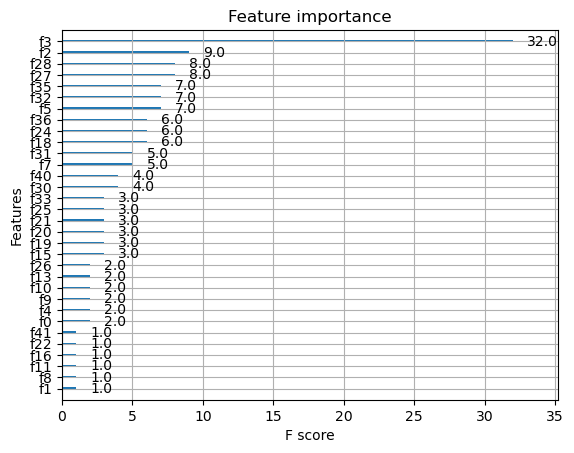

In [110]:
plot_importance(xgb_cv.best_estimator_)

In [195]:
df_1.columns

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_married', 'marital_single', 'education_secondary',
       'education_tertiary', 'education_unknown', 'default_yes', 'housing_yes',
       'loan_yes', 'contact_telephone', 'contact_unknown', 'month_aug',
       'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun',
       'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep',
       'poutcome_other', 'poutcome_success', 'poutcome_unknown', 'y_yes'],
      dtype='object')

### Top 3 most important features
1) Day
2) Balance
3 & 4) Education tertiary, Education unknown

### The marketing should look into the following 4 features when designing marketing campaign to target them as they are the going to be the customers who is likely to subscribe.


In [111]:
xgb_param2 = {'max_depth': [1, 2, 3, 5],
            'min_child_weight': [1, 3, 5],
            'learning_rate': [0.1, 0.2, 0.3],
            'n_estimators':[20, 25, 30, 40, 50]}
xgb_cv_2 = RandomizedSearchCV(xgb, xgb_param2, scoring=scoring, cv=5, refit='f1', n_iter=50, verbose=2, n_jobs=-1)


In [115]:
xgb_cv_2.fit(X_train_res, y_train_res, verbose=True)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate...
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None,
                                           random_state=0, ...),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'learning_rate': [0.1, 0.2, 0.3],
                                        'max_depth': [1, 2, 3, 5],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [20, 25, 30, 40, 50]},
                   refit='f1',
                   scoring={'accuracy': 'accuracy', 'f1': 'f1',
                            'precision': 'precision', 'recall': 'recall'},
                   verbose=2)

In [116]:
xgb_cv_2.best_params_

{'n_estimators': 50,
 'min_child_weight': 3,
 'max_depth': 2,
 'learning_rate': 0.2}

In [139]:
xgb_2_accuracy = accuracy_score(y_test, xgb_y_pred)
xgb_2_precision =  precision_score(y_test, xgb_y_pred)
xgb_2_recall = recall_score(y_test, xgb_y_pred)
xgb_2_f1 = f1_score(y_test, xgb_y_pred)
xgb_2_results = pd.DataFrame({'Model':[f"XGB2"],
                          'F1': [xgb_2_f1],
                          'Recall': [xgb_2_recall],
                          'Precision': [xgb_2_precision],
                          'Accuracy': [xgb_2_accuracy]})
xgb_2_results

,Model,F1,Recall,Precision,Accuracy
0,XGB2,0.565417,0.65053,0.5,0.88304


In [140]:
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense

In [143]:
#Building Neural Network Model
model = Sequential()

#Input layer
model.add(Dense(units=32, activation='relu', input_dim=X_train_res.shape[1]))

#3 hidden dense layer
model.add(Dense(units=128, activation='relu'))
model.add(Dense(units=64, activation='relu'))
model.add(Dense(units=32, activation='relu'))

#Output layer
model.add(Dense(units=1, activation='sigmoid'))
          

In [145]:
#compiling model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [147]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [149]:
model.fit(X_train_res, y_train_res, epochs=300, batch_size=32, callbacks=[early_stopping])

Epoch 1/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8971 - loss: 0.2447
Epoch 2/300
  75/1872 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9328 - loss: 0.1577 

C:\Users\Lim Otto\anaconda3\Lib\site-packages\keras\src\callbacks\early_stopping.py:155: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9324 - loss: 0.1576
Epoch 3/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9374 - loss: 0.1454
Epoch 4/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9392 - loss: 0.1410
Epoch 5/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9413 - loss: 0.1365
Epoch 6/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9402 - loss: 0.1349
Epoch 7/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9429 - loss: 0.1318
Epoch 8/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9458 - loss: 0.1264
Epoch 9/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9465 - loss: 0.1248
Epoch 10/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9481 - loss: 0.1220
Epoch 11/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9480 - loss: 0.1187
Epoch 12/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9503 - loss: 0.1165
Epoch 13/300
1872/1872 ━━━━━━━

1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9868 - loss: 0.0339
Epoch 69/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9845 - loss: 0.0361
Epoch 70/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9858 - loss: 0.0365
Epoch 71/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9866 - loss: 0.0329
Epoch 72/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9871 - loss: 0.0347
Epoch 73/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9861 - loss: 0.0349
Epoch 74/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9863 - loss: 0.0328
Epoch 75/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9861 - loss: 0.0345
Epoch 76/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9876 - loss: 0.0310
Epoch 77/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9875 - loss: 0.0323
Epoch 78/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9854 - loss: 0.0375
Epoch 79/300
1872/1872 

1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9922 - loss: 0.0208
Epoch 134/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9938 - loss: 0.0177
Epoch 135/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9936 - loss: 0.0171
Epoch 136/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9936 - loss: 0.0173
Epoch 137/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9933 - loss: 0.0195
Epoch 138/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9932 - loss: 0.0214
Epoch 139/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9935 - loss: 0.0173
Epoch 140/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9930 - loss: 0.0197
Epoch 141/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9942 - loss: 0.0174
Epoch 142/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9929 - loss: 0.0201
Epoch 143/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9939 - loss: 0.0162
Epoch 144/300

1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9953 - loss: 0.0128
Epoch 199/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9954 - loss: 0.0134
Epoch 200/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9956 - loss: 0.0126
Epoch 201/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9954 - loss: 0.0122
Epoch 202/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9959 - loss: 0.0134
Epoch 203/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9943 - loss: 0.0161
Epoch 204/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9961 - loss: 0.0121
Epoch 205/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9951 - loss: 0.0144
Epoch 206/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9967 - loss: 0.0101
Epoch 207/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9961 - loss: 0.0117
Epoch 208/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9959 - loss: 0.0116
Epoch 209/300

1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9957 - loss: 0.0135
Epoch 264/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9963 - loss: 0.0108
Epoch 265/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9965 - loss: 0.0097
Epoch 266/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9965 - loss: 0.0105
Epoch 267/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9974 - loss: 0.0075
Epoch 268/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9954 - loss: 0.0140
Epoch 269/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9971 - loss: 0.0090
Epoch 270/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9969 - loss: 0.0093
Epoch 271/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9971 - loss: 0.0087
Epoch 272/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9966 - loss: 0.0094
Epoch 273/300
1872/1872 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9972 - loss: 0.0087
Epoch 274/300

In [150]:
tf_pred = model.predict(X_test)

354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [153]:
tf_pred = [0 if val <0.5 else 1 for val in tf_pred]

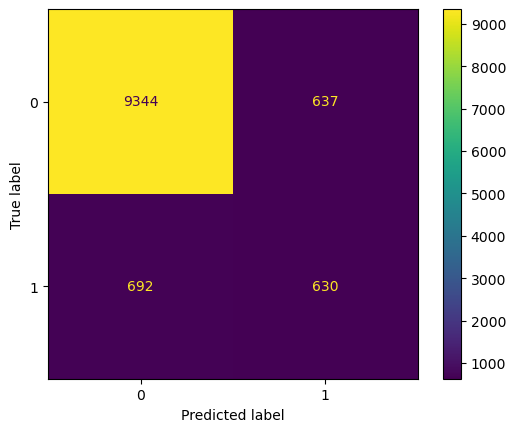

In [154]:
tf_pred_cm = confusion_matrix(y_test, tf_pred)
# Create display of confusion matrix
tf_disp = ConfusionMatrixDisplay(confusion_matrix=tf_pred_cm,
display_labels=gnb.classes_)
# Plot confusion matrix
tf_disp.plot(values_format='')
# Display plot
plt.show()

In [156]:
accuracy = accuracy_score(y_test, tf_pred)
precision =  precision_score(y_test, tf_pred)
recall = recall_score(y_test, tf_pred)
f1 = f1_score(y_test, tf_pred)
tf_results = pd.DataFrame({'Model':[f"TensorFlow"],
                          'F1': [f1],
                          'Recall': [recall],
                          'Precision': [precision],
                          'Accuracy': [accuracy]})
tf_results

,Model,F1,Recall,Precision,Accuracy
0,TensorFlow,0.486674,0.476551,0.497238,0.882421


## Combining all ML metrics results for comparison

In [159]:
all_results = pd.concat([tf_results,xgb_results,xgb_2_results,rf_clf_results,dt_clf_results,gnb_results,svc_rbf_results,svc_poly_results,svc_linear_results], ignore_index=True)
all_results

,Model,F1,Recall,Precision,Accuracy
0,TensorFlow,0.486674,0.476551,0.497238,0.882421
1,XGB,0.565417,0.650530,0.500000,0.883040
2,XGB2,0.565417,0.650530,0.500000,0.883040
3,Random Forest,0.515054,0.608169,0.446667,0.866053
4,Decision Tree,0.508557,0.550681,0.472421,0.875520
5,GNB,0.337953,0.433434,0.276945,0.801380
6,SVC_RBF,0.337953,0.433434,0.276945,0.801380
7,SVC_POLY,0.503448,0.496974,0.510093,0.885340
8,SVC_LINEAR,0.491935,0.461422,0.526770,0.888525


## Visualizing across all models with metrics

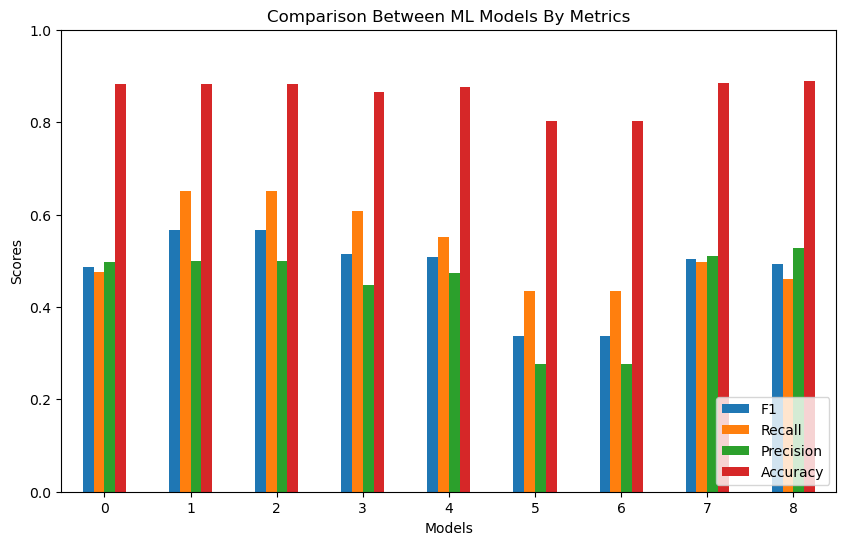

In [162]:
all_results.plot(kind='bar', figsize=(10, 6))
plt.title('Comparison Between ML Models By Metrics')
plt.xlabel('Models')
plt.ylabel('Scores')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.xticks(rotation=0)
plt.show()

# Conclusion
Based on the performance metrics of various models you've shared, here’s a brief analysis of their effectiveness:

1) XGB and XGB2 have the highest recall (0.650530) and a balanced F1 score (0.565417), indicating strong performance in     identifying positive instances, though with moderate precision.
2) Random Forest also performs well with a good recall (0.608169) and F1 score (0.515054).
3) Decision Tree has a decent balance with a moderate F1 score (0.508557) and recall (0.550681).
4) SVC_POLY shows balanced performance in precision (0.510093) and F1 score (0.503448).
5) SVC_LINEAR has high precision (0.526770) but lower recall (0.461422).
6) Given these metrics, XGB (XGBoost) seems to be the most robust overall, particularly in recall, which is crucial for ensuring that positive instances are not missed.

## Attempting to further refine Neural Network By Adjusting Hyperparameters And Optimizers With Different Layering

In [166]:
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam

model2 = Sequential()

# Input layer
model2.add(Dense(units=32, activation='relu', input_dim=X_train_res.shape[1]))
model2.add(BatchNormalization())

# Hidden dense layers
model2.add(Dense(units=128, activation='relu'))
model2.add(BatchNormalization())
model2.add(Dropout(0.5))

model2.add(Dense(units=64, activation='relu'))
model2.add(BatchNormalization())
model2.add(Dropout(0.5))

model2.add(Dense(units=32, activation='relu'))
model2.add(BatchNormalization())
model2.add(Dropout(0.5))

# Output layer
model2.add(Dense(units=1, activation='sigmoid'))

In [167]:
# Compile the model
model2.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Fit the model
model2.fit(X_train_res, y_train_res, epochs=300, batch_size=32, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/300
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 23s 4ms/step - accuracy: 0.7995 - loss: 0.4583 - val_accuracy: 0.9750 - val_loss: 0.0708
Epoch 2/300
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8998 - loss: 0.2479 - val_accuracy: 0.9648 - val_loss: 0.0861
Epoch 3/300
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9010 - loss: 0.2349 - val_accuracy: 0.9745 - val_loss: 0.0703
Epoch 4/300
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9069 - loss: 0.2231 - val_accuracy: 0.9784 - val_loss: 0.0653
Epoch 5/300
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9081 - loss: 0.2193 - val_accuracy: 0.9780 - val_loss: 0.0607
Epoch 6/300
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9075 - loss: 0.2201 - val_accuracy: 0.9775 - val_loss: 0.0641
Epoch 7/300
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9074 - loss: 0.2157 - val_accuracy: 0.9838 - val_loss: 0.0463
Epoch 8/300
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9114 - loss: 

In [168]:
tf2_pred = model2.predict(X_test)

354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [170]:
tf2_pred = [0 if val <0.5 else 1 for val in tf2_pred]

In [171]:
tf2_accuracy = accuracy_score(y_test, tf2_pred)
tf2_precision =  precision_score(y_test, tf2_pred)
tf2_recall = recall_score(y_test, tf2_pred)
tf2_f1 = f1_score(y_test, tf2_pred)
tf2_results = pd.DataFrame({'Model':[f"TensorFlow2"],
                          'F1': [tf2_f1],
                          'Recall': [tf2_recall],
                          'Precision': [tf2_precision],
                          'Accuracy': [tf2_accuracy]})
tf2_results

,Model,F1,Recall,Precision,Accuracy
0,TensorFlow2,0.550039,0.527988,0.574013,0.898965


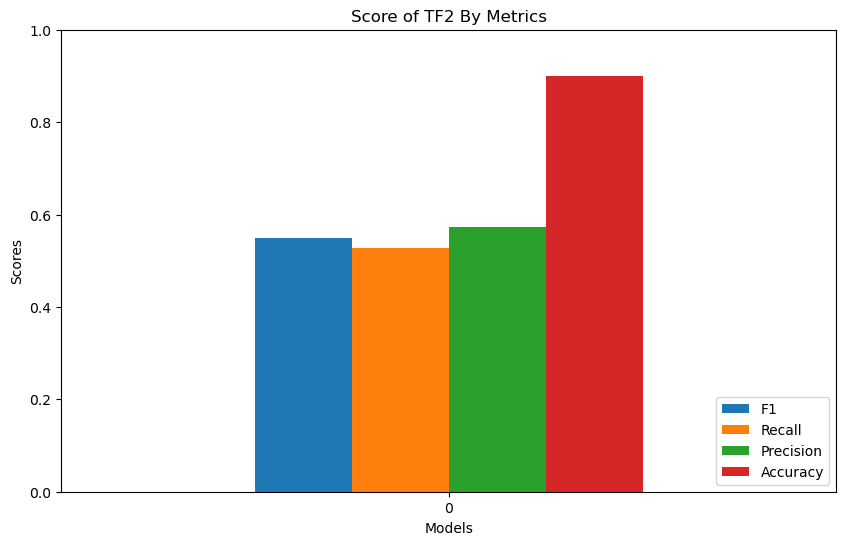

In [180]:
tf2_results.plot(kind='bar', figsize=(10, 6))
plt.title('Score of TF2 By Metrics')
plt.xlabel('Models')
plt.ylabel('Scores')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.xticks(rotation=0)
plt.show()

In [174]:
from tensorflow.keras.optimizers import Adam, RMSprop
model3 = Sequential()

# Input layer
model3.add(Dense(units=64, activation='relu', input_dim=X_train_res.shape[1]))
model3.add(BatchNormalization())
model3.add(Dropout(0.5))

# Hidden dense layers
model3.add(Dense(units=128, activation='relu'))
model3.add(BatchNormalization())
model3.add(Dropout(0.5))

model3.add(Dense(units=64, activation='relu'))
model3.add(BatchNormalization())
model3.add(Dropout(0.5))

model3.add(Dense(units=32, activation='relu'))
model3.add(BatchNormalization())
model3.add(Dropout(0.5))

# Output layer
model3.add(Dense(units=1, activation='sigmoid'))

C:\Users\Lim Otto\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [175]:
# Compile the model
model3.compile(loss='binary_crossentropy', optimizer=RMSprop(learning_rate=0.0001), metrics=['accuracy'])

# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)


In [176]:
# Fit the model
model3.fit(X_train_res, y_train_res, epochs=500, batch_size=16, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/500
2995/2995 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.5876 - loss: 0.7939 - val_accuracy: 0.9794 - val_loss: 0.1754
Epoch 2/500
2995/2995 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.7885 - loss: 0.4753 - val_accuracy: 0.9761 - val_loss: 0.1135
Epoch 3/500
2995/2995 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8500 - loss: 0.3744 - val_accuracy: 0.9836 - val_loss: 0.0851
Epoch 4/500
2995/2995 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8657 - loss: 0.3445 - val_accuracy: 0.9828 - val_loss: 0.0869
Epoch 5/500
2995/2995 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8766 - loss: 0.3169 - val_accuracy: 0.9835 - val_loss: 0.0865
Epoch 6/500
2995/2995 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8825 - loss: 0.2992 - val_accuracy: 0.9836 - val_loss: 0.0763
Epoch 7/500
2995/2995 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8836 - loss: 0.2980 - val_accuracy: 0.9809 - val_loss: 0.0865
Epoch 8/500
2995/2995 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8871 - loss:

In [178]:
tf3_pred = model3.predict(X_test)

354/354 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [179]:
tf3_pred = [0 if val <0.5 else 1 for val in tf3_pred]

In [184]:
tf3_accuracy = accuracy_score(y_test, tf3_pred)
tf3_precision =  precision_score(y_test, tf3_pred)
tf3_recall = recall_score(y_test, tf3_pred)
tf3_f1 = f1_score(y_test, tf3_pred)
tf3_results = pd.DataFrame({'Model':[f"TensorFlow3"],
                          'F1': [tf3_f1],
                          'Recall': [tf3_recall],
                          'Precision': [tf3_precision],
                          'Accuracy': [tf3_accuracy]})
tf3_results

,Model,F1,Recall,Precision,Accuracy
0,TensorFlow3,0.520112,0.493949,0.549201,0.893391


In [185]:
all_tf_results = pd.concat([tf3_results, tf2_results, tf_results], ignore_index=True)
all_tf_results

,Model,F1,Recall,Precision,Accuracy
0,TensorFlow3,0.520112,0.493949,0.549201,0.893391
1,TensorFlow2,0.550039,0.527988,0.574013,0.898965
2,TensorFlow,0.486674,0.476551,0.497238,0.882421


In [187]:
all_results

,Model,F1,Recall,Precision,Accuracy
0,TensorFlow,0.486674,0.476551,0.497238,0.882421
1,XGB,0.565417,0.650530,0.500000,0.883040
2,XGB2,0.565417,0.650530,0.500000,0.883040
3,Random Forest,0.515054,0.608169,0.446667,0.866053
4,Decision Tree,0.508557,0.550681,0.472421,0.875520
5,GNB,0.337953,0.433434,0.276945,0.801380
6,SVC_RBF,0.337953,0.433434,0.276945,0.801380
7,SVC_POLY,0.503448,0.496974,0.510093,0.885340
8,SVC_LINEAR,0.491935,0.461422,0.526770,0.888525


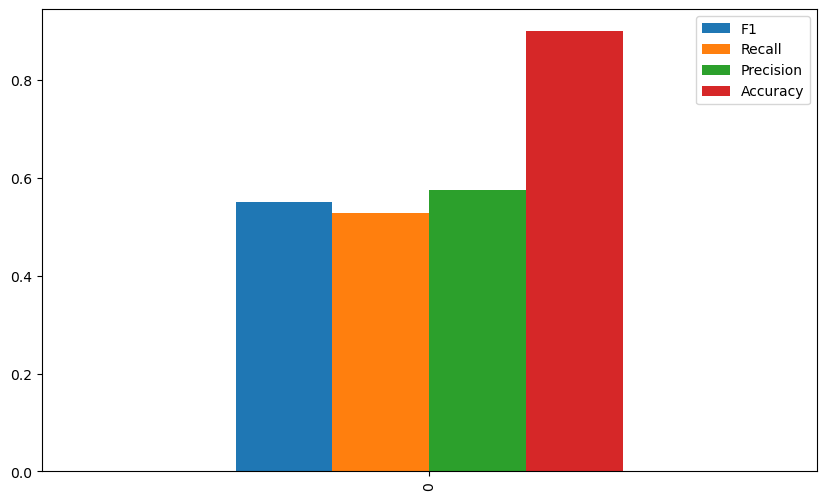

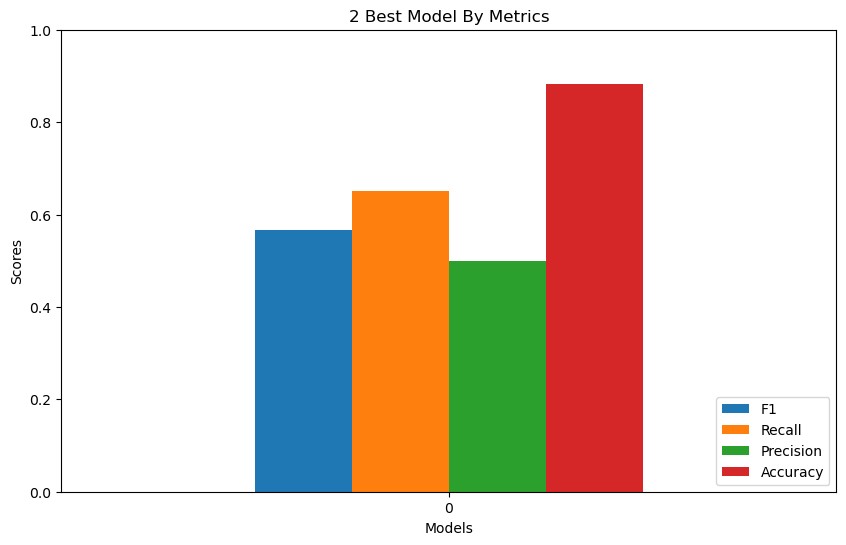

In [192]:

tf2_results.plot(kind='bar', figsize=(10, 6))
xgb_results.plot(kind='bar', figsize=(10, 6))

plt.title('2 Best Model By Metrics')
plt.xlabel('Models')
plt.ylabel('Scores')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.xticks(rotation=0)
plt.show()

## TF Model 2 had seen some improvements but still yet to be ready for deployment, will keep tuning to enhance the overall peformance.

## XGBoost is still better than TF2 and proven more resilient based on its overall scores, this might due to the complexity of the datasets and size